# Lab 02: NUMPY FOR DATA SCIENCE
## Bài toán: Dự đoán khả năng có thay đổi công việc Khoa học dữ liệu

## Khám phá dữ liệu

In [ ]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
from src import visualization as vis
import numpy as np
import math

In [2]:
file_path = '../data/raw/aug_train.csv'

data = np.genfromtxt(file_path, delimiter=',', dtype=str, skip_header=1)
headers = np.genfromtxt(file_path, delimiter=',', dtype=str, max_rows=1)

print("Headers:", headers)
print("Data mẫu:", data[:5])

Headers: ['enrollee_id' 'city' 'city_development_index' 'gender'
 'relevent_experience' 'enrolled_university' 'education_level'
 'major_discipline' 'experience' 'company_size' 'company_type'
 'last_new_job' 'training_hours' 'target']
Data mẫu: [['8949' 'city_103' '0.92' 'Male' 'Has relevent experience'
  'no_enrollment' 'Graduate' 'STEM' '>20' '' '' '1' '36' '1.0']
 ['29725' 'city_40' '0.7759999999999999' 'Male' 'No relevent experience'
  'no_enrollment' 'Graduate' 'STEM' '15' '50-99' 'Pvt Ltd' '>4' '47'
  '0.0']
 ['11561' 'city_21' '0.624' '' 'No relevent experience'
  'Full time course' 'Graduate' 'STEM' '5' '' '' 'never' '83' '0.0']
 ['33241' 'city_115' '0.789' '' 'No relevent experience' '' 'Graduate'
  'Business Degree' '<1' '' 'Pvt Ltd' 'never' '52' '1.0']
 ['666' 'city_162' '0.767' 'Male' 'Has relevent experience'
  'no_enrollment' 'Masters' 'STEM' '>20' '50-99' 'Funded Startup' '4' '8'
  '0.0']]


In [32]:
print("=== TỔNG QUAN BỘ DỮ LIỆU ===")

# Thông tin cơ bản
num_rows, num_cols = data.shape
dataset_size = data.size

print("\n--- Thông tin cơ bản ---")
print(f"Bộ dữ liệu có {num_rows} dòng")
print(f"Bộ dữ liệu có {num_cols} cột ")
print(f"Tổng kích thước dữ liệu: {dataset_size} phần tử")
print("Ý nghĩa mỗi dòng: Mỗi dòng đại diện cho một ứng viên (enrollee) và thông tin liên quan đến họ.")

# Tính toàn vẹn dữ liệu
print("\n--- Tính toàn vẹn dữ liệu ---")
unique_rows = np.unique(data, axis=0)
num_duplicates = num_rows - unique_rows.shape[0]

print(f"Có {num_duplicates} dòng bị trùng lặp")

missing_mask = (data == '') | (data == 'nan')
missing_count_per_row = np.einsum('ij->i', missing_mask.astype(int))

num_empty_rows = np.sum(missing_count_per_row == num_cols)
num_incomplete_rows = np.sum(missing_count_per_row > 0)

print(f"Số dòng trống hoàn toàn: {num_empty_rows}")
if num_incomplete_rows == 0:
    print("Tất cả các dòng đều đầy đủ.")
else:
    print(f"Có {num_incomplete_rows} dòng bị thiếu ít nhất một giá trị.")

# Danh sách cột và ý nghĩa
print("\n--- Danh sách cột và ý nghĩa ---")
data_dictionary = {
    "enrollee_id": "ID duy nhất của ứng viên.",
    "city": "Mã thành phố.",
    "city_development_index": "Chỉ số phát triển của thành phố (đã được chuẩn hóa).",
    "gender": "Giới tính của ứng viên.",
    "relevent_experience": "Kinh nghiệm liên quan của ứng viên.",
    "enrolled_university": "Loại hình khóa học đại học đã đăng ký (nếu có).",
    "education_level": "Trình độ học vấn của ứng viên.",
    "major_discipline": "Chuyên ngành học của ứng viên.",
    "experience": "Tổng số năm kinh nghiệm làm việc của ứng viên.",
    "company_size": "Số lượng nhân viên tại công ty hiện tại.",
    "company_type": "Loại hình công ty hiện tại.",
    "last_new_job": "Khoảng cách số năm giữa công việc trước đó và hiện tại.",
    "training_hours": "Số giờ đào tạo đã hoàn thành.",
    "target": "0 – Không tìm việc mới, 1 – Đang tìm việc mới."
}


print(f"{'Tên cột':<25} | {'Ý nghĩa'}")
print("-" * 80)

for key, value in data_dictionary.items():
    print(f"{key:<25} | {value}")

# Danh sách cột & Kiểu dữ liệu
print("\n--- Danh sách cột và Kiểu dữ liệu ---")
print(f"{'Tên cột':<25} | {'Kiểu hiện tại':<15} | {'Kiểu thực tế':<25}")
print("-" * 70)


# Xử lý chuỗi 

temp_check = np.char.replace(data, '.', '')
temp_check = np.char.replace(temp_check, '-', '')

# Kiểm tra isdigit trên toàn bộ mảng đã làm sạch
is_digit_matrix = np.char.isdigit(temp_check) | missing_mask

# Xác định cột số
is_numeric_col_mask = np.all(is_digit_matrix, axis=0)

# Chuẩn bị dữ liệu để in 
cols_to_drop = headers[headers == 'enrollee_id'].tolist() 
relevant_cols = headers[headers != 'enrollee_id'].tolist() 

for i, col_name in enumerate(headers):
    current_type = "String (str)"
    
    # Lấy kết quả từ mask đã tính toán bên trên (O(1) lookup)
    if is_numeric_col_mask[i]:
         inferred_type = "Numeric (Số)"
    else:
         inferred_type = "Categorical/String"
         
    print(f"{col_name:<25} | {current_type:<15} | {inferred_type:<25}")

=== TỔNG QUAN BỘ DỮ LIỆU ===

--- Thông tin cơ bản ---
Bộ dữ liệu có 19158 dòng
Bộ dữ liệu có 14 cột 
Tổng kích thước dữ liệu: 268212 phần tử
Ý nghĩa mỗi dòng: Mỗi dòng đại diện cho một ứng viên (enrollee) và thông tin liên quan đến họ.

--- Tính toàn vẹn dữ liệu ---
Có 0 dòng bị trùng lặp
Số dòng trống hoàn toàn: 0
Có 10203 dòng bị thiếu ít nhất một giá trị.

--- Danh sách cột và ý nghĩa ---
Tên cột                   | Ý nghĩa
--------------------------------------------------------------------------------
enrollee_id               | ID duy nhất của ứng viên.
city                      | Mã thành phố.
city_development_index    | Chỉ số phát triển của thành phố (đã được chuẩn hóa).
gender                    | Giới tính của ứng viên.
relevent_experience       | Kinh nghiệm liên quan của ứng viên.
enrolled_university       | Loại hình khóa học đại học đã đăng ký (nếu có).
education_level           | Trình độ học vấn của ứng viên.
major_discipline          | Chuyên ngành học của ứng viên.


=== PHÂN TÍCH CỘT SỐ (NUMERICAL ANALYSIS) ===

--- Phân tích cột: city_development_index ---
Phân phối & Xu hướng tập trung:
   Trung bình (Mean): 0.8288
   Trung vị (Median): 0.9030
   Độ lệch chuẩn (Std): 0.1234
    Hình dạng phân phối (Sơ bộ): Lệch trái (Left skewed) - Giá trị nhỏ kéo trung bình xuống thấp.
Phạm vi & Ngoại lai (Outliers):
   Min: 0.44799999999999995 | Max: 0.9490000000000001
   Số lượng ngoại lai (IQR method): 17 (0.09%)
Chất lượng dữ liệu:
   Tỉ lệ thiếu (Missing): 0.00%
   Không có giá trị âm vô lý.


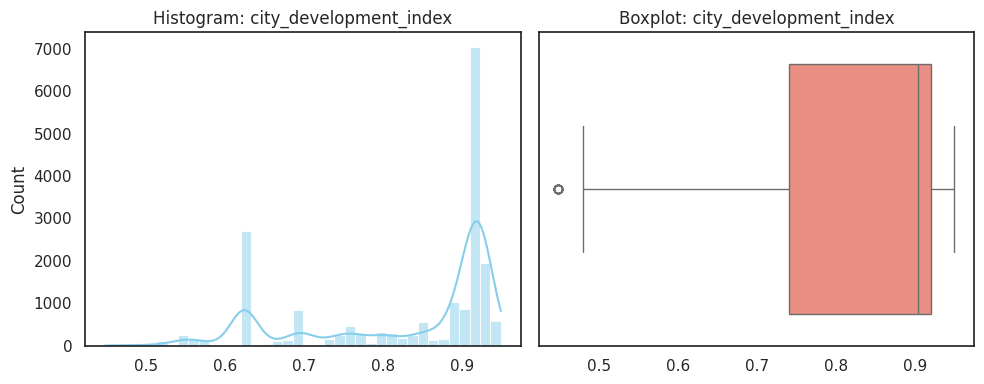



--- Phân tích cột: training_hours ---
Phân phối & Xu hướng tập trung:
   Trung bình (Mean): 65.3669
   Trung vị (Median): 47.0000
   Độ lệch chuẩn (Std): 60.0569
    Hình dạng phân phối (Sơ bộ): Lệch phải (Right skewed) - Giá trị lớn kéo trung bình lên cao.
Phạm vi & Ngoại lai (Outliers):
   Min: 1.0 | Max: 336.0
   Số lượng ngoại lai (IQR method): 984 (5.14%)
Chất lượng dữ liệu:
   Tỉ lệ thiếu (Missing): 0.00%
   Không có giá trị âm vô lý.


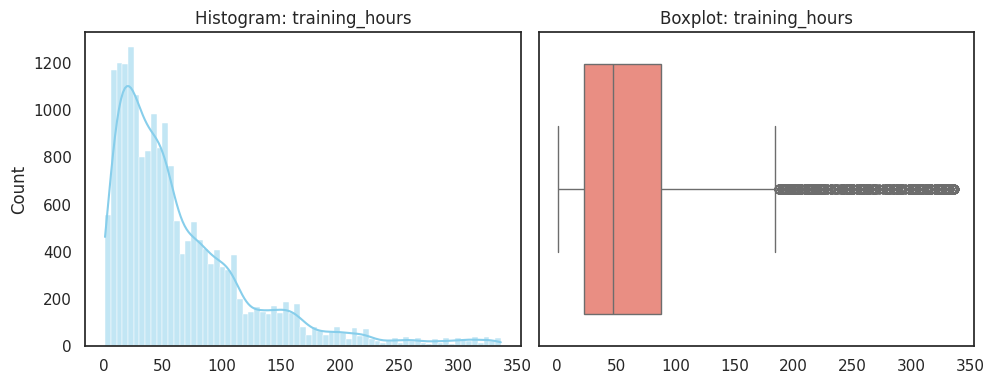



--- Phân tích cột: target ---
Phân phối & Xu hướng tập trung:
   Trung bình (Mean): 0.2493
   Trung vị (Median): 0.0000
   Độ lệch chuẩn (Std): 0.4326
    Hình dạng phân phối (Sơ bộ): Lệch phải (Right skewed) - Giá trị lớn kéo trung bình lên cao.
Phạm vi & Ngoại lai (Outliers):
   Min: 0.0 | Max: 1.0
   Số lượng ngoại lai (IQR method): 4777 (24.93%)
Chất lượng dữ liệu:
   Tỉ lệ thiếu (Missing): 0.00%
   Không có giá trị âm vô lý.


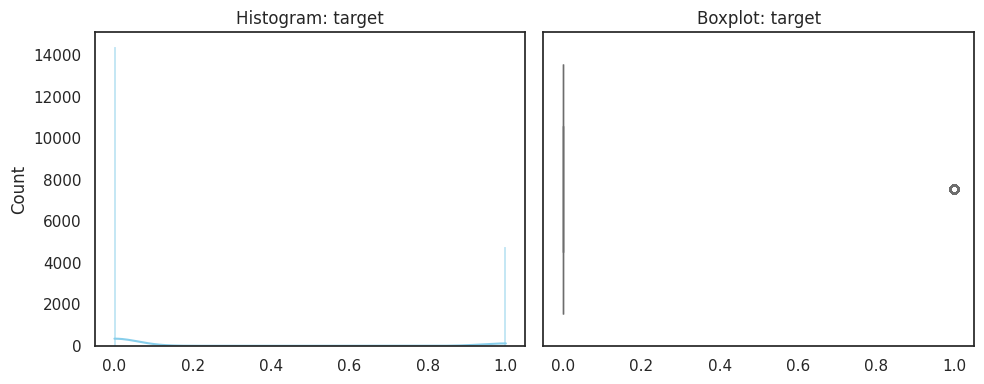

In [34]:
print("=== PHÂN TÍCH CỘT SỐ (NUMERICAL ANALYSIS) ===\n")

# Lấy cột số
numerical_cols = ['city_development_index', 'training_hours', 'target']
col_indices = [np.where(headers == name)[0][0] for name in numerical_cols]
raw_nums = data[:, col_indices]

# Chuyển đổi sang float và xử lý Missing Value thành NaN để tính toán thống kê
raw_nums[raw_nums == ''] = np.nan
raw_nums[raw_nums == 'nan'] = np.nan
X_nums = raw_nums.astype(float) # Ma trận (N_rows x 3_cols)

# Thống kê mô tả
means = np.nanmean(X_nums, axis=0)
medians = np.nanmedian(X_nums, axis=0)
stds = np.nanstd(X_nums, axis=0)
mins = np.nanmin(X_nums, axis=0)
maxs = np.nanmax(X_nums, axis=0)

# Tính phân vị
q1s = np.nanpercentile(X_nums, 25, axis=0)
q3s = np.nanpercentile(X_nums, 75, axis=0)
iqrs = q3s - q1s

# Tính outlier 
lower_bounds = q1s - 1.5 * iqrs
upper_bounds = q3s + 1.5 * iqrs

# Tạo mask ngoại lai cho toàn bộ ma trận: So sánh (N,3) với (3,)
# Kết quả là ma trận Boolean (N,3)
outliers_mask = (X_nums < lower_bounds) | (X_nums > upper_bounds)
num_outliers_per_col = np.sum(outliers_mask, axis=0) # Đếm theo cột

# Kiểm tra chất lượng dữ liệu
missing_counts = np.sum(np.isnan(X_nums), axis=0)
negative_counts = np.sum(X_nums < 0, axis=0)
total_rows = X_nums.shape[0]

# In
for i, col_name in enumerate(numerical_cols):
    print(f"--- Phân tích cột: {col_name} ---")

    mean_val = means[i]
    median_val = medians[i]
    std_val = stds[i]
    
    print("Phân phối & Xu hướng tập trung:")
    print(f"   Trung bình (Mean): {mean_val:.4f}")
    print(f"   Trung vị (Median): {median_val:.4f}")
    print(f"   Độ lệch chuẩn (Std): {std_val:.4f}")
    
    # Đánh giá độ lệch 
    if mean_val > median_val:
        shape_desc = "Lệch phải (Right skewed) - Giá trị lớn kéo trung bình lên cao."
    elif mean_val < median_val:
        shape_desc = "Lệch trái (Left skewed) - Giá trị nhỏ kéo trung bình xuống thấp."
    else:
        shape_desc = "Đối xứng (Symmetric)."
    print(f"    Hình dạng phân phối (Sơ bộ): {shape_desc}")

    # Outliers 
    num_out = num_outliers_per_col[i]
    valid_count = total_rows - missing_counts[i]
    pct_outliers = (num_out / valid_count) * 100 if valid_count > 0 else 0

    print("Phạm vi & Ngoại lai (Outliers):")
    print(f"   Min: {mins[i]} | Max: {maxs[i]}")
    print(f"   Số lượng ngoại lai (IQR method): {num_out} ({pct_outliers:.2f}%)")
    
    # Chất lượng dữ liệu
    missing_pct = (missing_counts[i] / total_rows) * 100
    
    print("Chất lượng dữ liệu:")
    print(f"   Tỉ lệ thiếu (Missing): {missing_pct:.2f}%")
    if negative_counts[i] > 0:
        print(f"   CẢNH BÁO: Có {negative_counts[i]} giá trị âm (vô lý).")
    else:
        print("   Không có giá trị âm vô lý.")
    
    # Vẽ biểu đồ 
    # Lấy cột dữ liệu hiện tại để vẽ
    current_col_data = X_nums[:, i]
    plot_data = current_col_data[~np.isnan(current_col_data)]
    vis.plot_numerical_distribution(plot_data, col_name)
    
    print("\n")

=== PHÂN TÍCH CỘT PHÂN LOẠI (CATEGORICAL ANALYSIS) ===

--- Phân tích cột: city ---
Chất lượng dữ liệu:
   Tỉ lệ thiếu (Missing): 0.00%
Phân phối giá trị:
   Số lượng giá trị duy nhất (Unique values): 123
   Top 10 giá trị phổ biến nhất:
      1. city_103: 4355 (22.73%)
      2. city_21: 2702 (14.10%)
      3. city_16: 1533 (8.00%)
      4. city_114: 1336 (6.97%)
      5. city_160: 845 (4.41%)
      6. city_136: 586 (3.06%)
      7. city_67: 431 (2.25%)
      8. city_75: 305 (1.59%)
      9. city_102: 304 (1.59%)
      10. city_104: 301 (1.57%)
   Đánh giá độ cân bằng: Tương đối cân bằng
Tính nhất quán: Tốt (Không có lỗi do viết hoa/thường).
   Các danh mục hiếm (<1%): 106 giá trị. Cân nhắc gộp nhóm 'Other'.


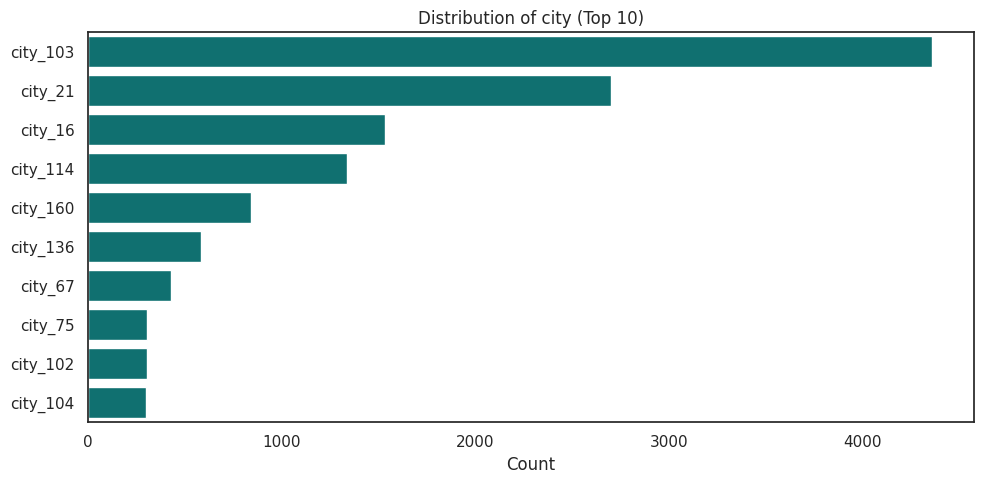



--- Phân tích cột: gender ---
Chất lượng dữ liệu:
   Tỉ lệ thiếu (Missing): 23.53%
Phân phối giá trị:
   Số lượng giá trị duy nhất (Unique values): 3
   Top 3 giá trị phổ biến nhất:
      1. Male: 13221 (90.25%)
      2. Female: 1238 (8.45%)
      3. Other: 191 (1.30%)
   Đánh giá độ cân bằng: Rất mất cân bằng (Highly Imbalanced)
Tính nhất quán: Tốt (Không có lỗi do viết hoa/thường).


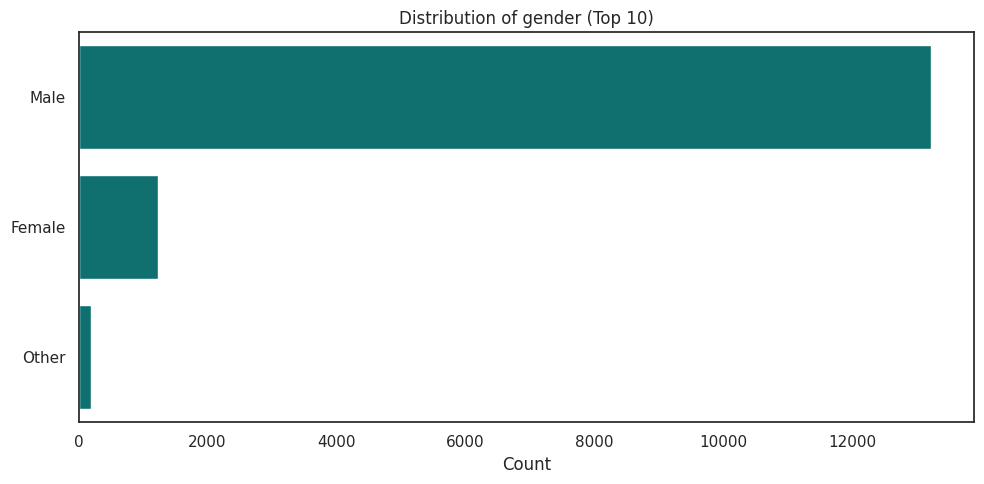



--- Phân tích cột: relevent_experience ---
Chất lượng dữ liệu:
   Tỉ lệ thiếu (Missing): 0.00%
Phân phối giá trị:
   Số lượng giá trị duy nhất (Unique values): 2
   Top 2 giá trị phổ biến nhất:
      1. Has relevent experience: 13792 (71.99%)
      2. No relevent experience: 5366 (28.01%)
   Đánh giá độ cân bằng: Mất cân bằng (Imbalanced)
Tính nhất quán: Tốt (Không có lỗi do viết hoa/thường).


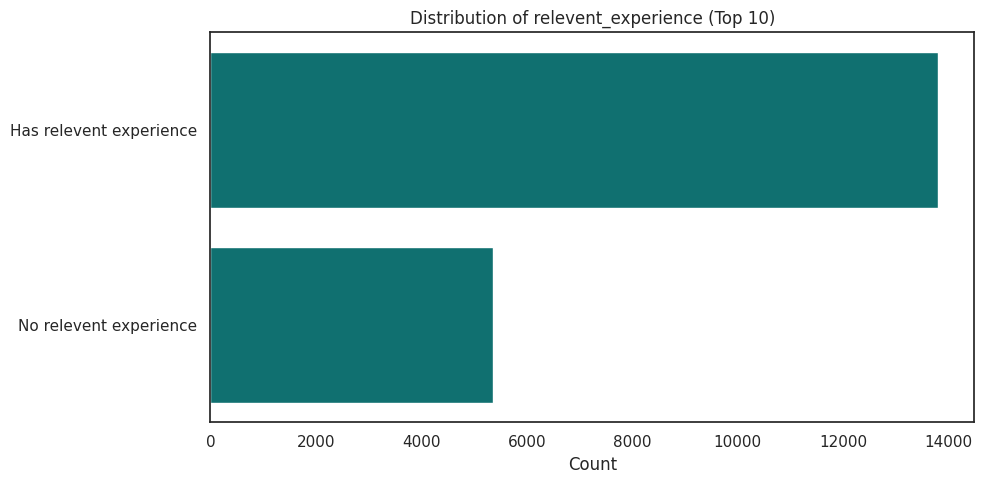



--- Phân tích cột: enrolled_university ---
Chất lượng dữ liệu:
   Tỉ lệ thiếu (Missing): 2.01%
Phân phối giá trị:
   Số lượng giá trị duy nhất (Unique values): 3
   Top 3 giá trị phổ biến nhất:
      1. no_enrollment: 13817 (73.60%)
      2. Full time course: 3757 (20.01%)
      3. Part time course: 1198 (6.38%)
   Đánh giá độ cân bằng: Mất cân bằng (Imbalanced)
Tính nhất quán: Tốt (Không có lỗi do viết hoa/thường).


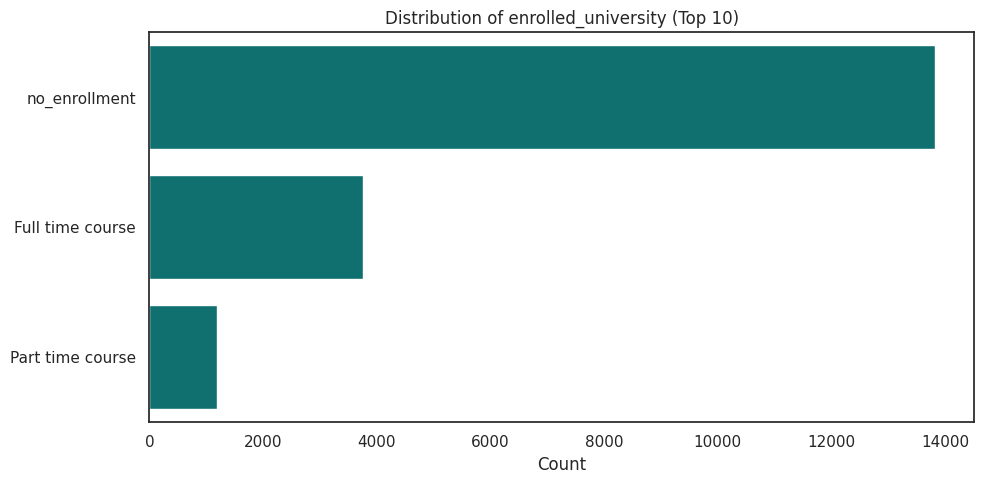



--- Phân tích cột: education_level ---
Chất lượng dữ liệu:
   Tỉ lệ thiếu (Missing): 2.40%
Phân phối giá trị:
   Số lượng giá trị duy nhất (Unique values): 5
   Top 5 giá trị phổ biến nhất:
      1. Graduate: 11598 (62.03%)
      2. Masters: 4361 (23.32%)
      3. High School: 2017 (10.79%)
      4. Phd: 414 (2.21%)
      5. Primary School: 308 (1.65%)
   Đánh giá độ cân bằng: Mất cân bằng (Imbalanced)
Tính nhất quán: Tốt (Không có lỗi do viết hoa/thường).


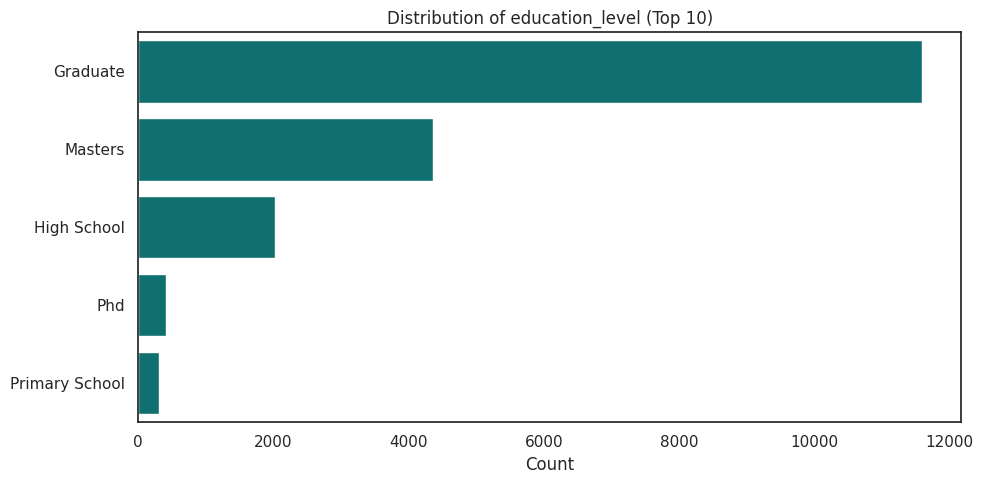



--- Phân tích cột: major_discipline ---
Chất lượng dữ liệu:
   Tỉ lệ thiếu (Missing): 14.68%
Phân phối giá trị:
   Số lượng giá trị duy nhất (Unique values): 6
   Top 6 giá trị phổ biến nhất:
      1. STEM: 14492 (88.66%)
      2. Humanities: 669 (4.09%)
      3. Other: 381 (2.33%)
      4. Business Degree: 327 (2.00%)
      5. Arts: 253 (1.55%)
      6. No Major: 223 (1.36%)
   Đánh giá độ cân bằng: Rất mất cân bằng (Highly Imbalanced)
Tính nhất quán: Tốt (Không có lỗi do viết hoa/thường).


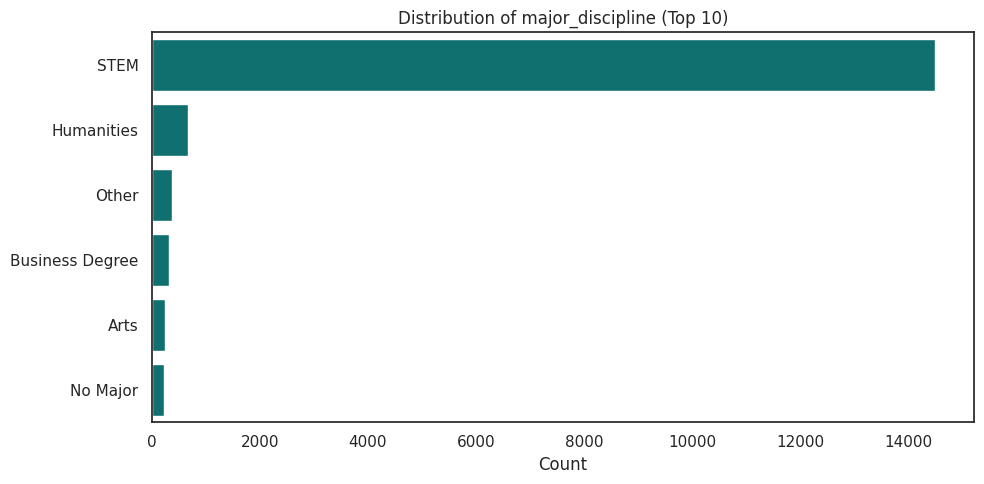



--- Phân tích cột: experience ---
Chất lượng dữ liệu:
   Tỉ lệ thiếu (Missing): 0.34%
Phân phối giá trị:
   Số lượng giá trị duy nhất (Unique values): 22
   Top 10 giá trị phổ biến nhất:
      1. >20: 3286 (17.21%)
      2. 5: 1430 (7.49%)
      3. 4: 1403 (7.35%)
      4. 3: 1354 (7.09%)
      5. 6: 1216 (6.37%)
      6. 2: 1127 (5.90%)
      7. 7: 1028 (5.38%)
      8. 10: 985 (5.16%)
      9. 9: 980 (5.13%)
      10. 8: 802 (4.20%)
   Đánh giá độ cân bằng: Tương đối cân bằng
Tính nhất quán: Tốt (Không có lỗi do viết hoa/thường).
   Các danh mục hiếm (<1%): 1 giá trị. Cân nhắc gộp nhóm 'Other'.


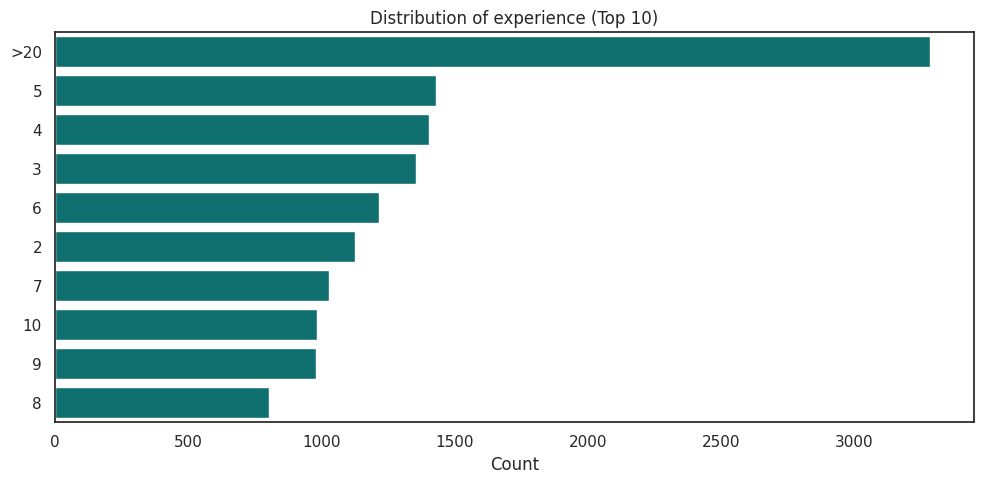



--- Phân tích cột: company_size ---
Chất lượng dữ liệu:
   Tỉ lệ thiếu (Missing): 30.99%
Phân phối giá trị:
   Số lượng giá trị duy nhất (Unique values): 8
   Top 8 giá trị phổ biến nhất:
      1. 50-99: 3083 (23.32%)
      2. 100-500: 2571 (19.45%)
      3. 10000+: 2019 (15.27%)
      4. 10/49: 1471 (11.13%)
      5. 1000-4999: 1328 (10.05%)
      6. <10: 1308 (9.89%)
      7. 500-999: 877 (6.63%)
      8. 5000-9999: 563 (4.26%)
   Đánh giá độ cân bằng: Tương đối cân bằng
Tính nhất quán: Tốt (Không có lỗi do viết hoa/thường).


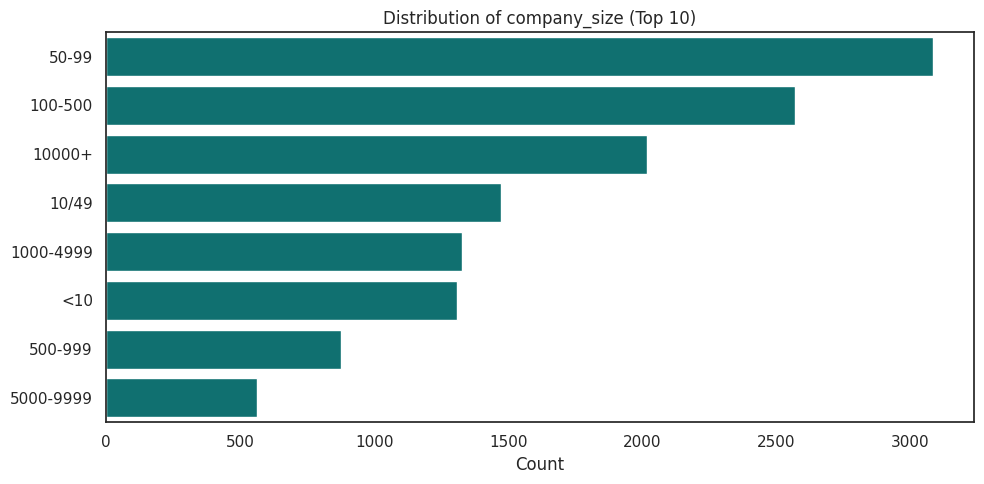



--- Phân tích cột: company_type ---
Chất lượng dữ liệu:
   Tỉ lệ thiếu (Missing): 32.05%
Phân phối giá trị:
   Số lượng giá trị duy nhất (Unique values): 6
   Top 6 giá trị phổ biến nhất:
      1. Pvt Ltd: 9817 (75.41%)
      2. Funded Startup: 1001 (7.69%)
      3. Public Sector: 955 (7.34%)
      4. Early Stage Startup: 603 (4.63%)
      5. NGO: 521 (4.00%)
      6. Other: 121 (0.93%)
   Đánh giá độ cân bằng: Mất cân bằng (Imbalanced)
Tính nhất quán: Tốt (Không có lỗi do viết hoa/thường).
   Các danh mục hiếm (<1%): 1 giá trị. Cân nhắc gộp nhóm 'Other'.


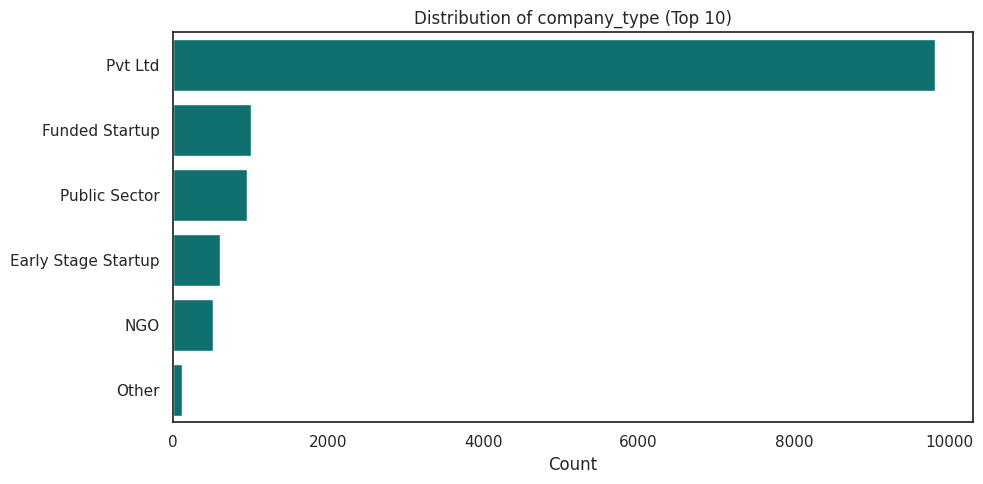



--- Phân tích cột: last_new_job ---
Chất lượng dữ liệu:
   Tỉ lệ thiếu (Missing): 2.21%
Phân phối giá trị:
   Số lượng giá trị duy nhất (Unique values): 6
   Top 6 giá trị phổ biến nhất:
      1. 1: 8040 (42.91%)
      2. >4: 3290 (17.56%)
      3. 2: 2900 (15.48%)
      4. never: 2452 (13.09%)
      5. 4: 1029 (5.49%)
      6. 3: 1024 (5.47%)
   Đánh giá độ cân bằng: Tương đối cân bằng
Tính nhất quán: Tốt (Không có lỗi do viết hoa/thường).


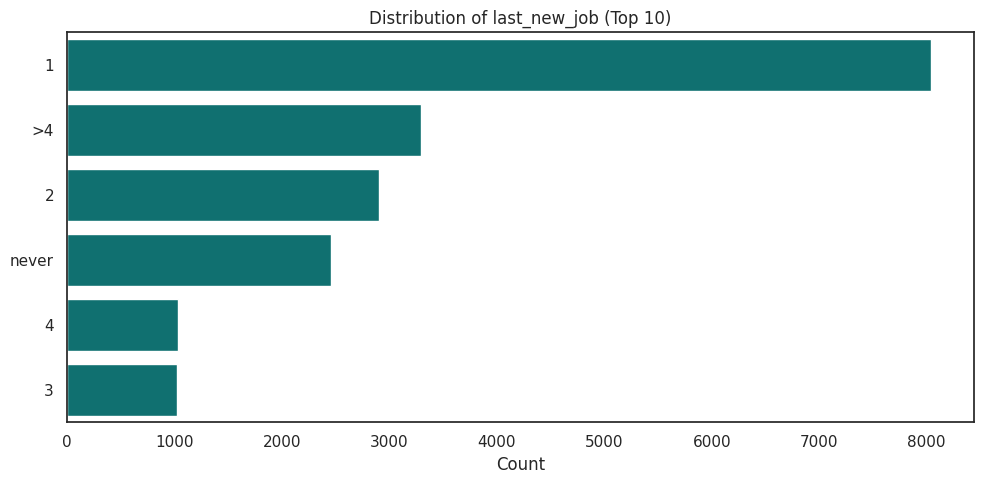

In [35]:
# Phân tích cột phân loại
categorical_cols = [
    'city', 'gender', 'relevent_experience', 'enrolled_university', 
    'education_level', 'major_discipline', 'experience', 
    'company_size', 'company_type', 'last_new_job'
]
# Lấy index
col_indices = [np.where(headers == name)[0][0] for name in categorical_cols]

print("=== PHÂN TÍCH CỘT PHÂN LOẠI (CATEGORICAL ANALYSIS) ===\n")

X_cat = data[:, col_indices]
total_rows = X_cat.shape[0]

# Tính giá trị thiếu
is_missing_matrix = (X_cat == '') | (X_cat == 'nan')
missing_counts_all = np.sum(is_missing_matrix, axis=0)

# Xử lý chuỗi
X_cat_lower = np.char.lower(X_cat)

# Duyệt qua từng cột
for i, col_name in enumerate(categorical_cols):
    print(f"--- Phân tích cột: {col_name} ---")
    
    # Lấy dữ liệu 
    raw_col = X_cat[:, i]
    
    # Lấy thông tin missing 
    missing_count = missing_counts_all[i]
    missing_pct = (missing_count / total_rows) * 100
    
    # Lọc dữ liệu để phân tích chi tiết (Masking)
    mask_col = is_missing_matrix[:, i]
    valid_data = raw_col[~mask_col]
    
    print("Chất lượng dữ liệu:")
    print(f"   Tỉ lệ thiếu (Missing): {missing_pct:.2f}%")
    
    if len(valid_data) == 0:
        print("   Cột trống hoàn toàn.\n")
        continue

    # Biểu diễn giá trị
    unique_vals, counts = np.unique(valid_data, return_counts=True)
    
    # Sắp xếp giảm dần 
    sorted_indices = np.argsort(-counts)
    sorted_vals = unique_vals[sorted_indices]
    sorted_counts = counts[sorted_indices]
    
    num_unique = len(unique_vals)
    
    print("Phân phối giá trị:")
    print(f"   Số lượng giá trị duy nhất (Unique values): {num_unique}")
    
    # In top giá trị phổ biến nhất
    top_n = min(10, num_unique)
    print(f"   Top {top_n} giá trị phổ biến nhất:")
    for k in range(top_n):
        pct = (sorted_counts[k] / len(valid_data)) * 100
        print(f"      {k+1}. {sorted_vals[k]}: {sorted_counts[k]} ({pct:.2f}%)")
        
    # Kiểm tra độ mất cân bằng 
    if len(sorted_counts) > 0: 
        top_1_pct = (sorted_counts[0] / len(valid_data)) * 100
        if top_1_pct > 80:
            balance_status = "Rất mất cân bằng (Highly Imbalanced)"
        elif top_1_pct > 50:
            balance_status = "Mất cân bằng (Imbalanced)"
        else:
            balance_status = "Tương đối cân bằng"
        print(f"   Đánh giá độ cân bằng: {balance_status}")
    
    # Kiểm tra tính nhất quán
    valid_data_lower = X_cat_lower[:, i][~mask_col] 
    unique_lower = np.unique(valid_data_lower)
    
    if len(unique_lower) < len(unique_vals):
        print("Tính nhất quán: Phát hiện không nhất quán chữ hoa/thường (Inconsistency).")
    else:
        print("Tính nhất quán: Tốt (Không có lỗi do viết hoa/thường).")
        
    # Kiểm tra danh mục hiếm (<1%) (Masking operation)
    rare_threshold = 0.01 * len(valid_data)
    rare_mask = sorted_counts < rare_threshold
    num_rare_vals = np.sum(rare_mask)
    
    if num_rare_vals > 0:
        print(f"   Các danh mục hiếm (<1%): {num_rare_vals} giá trị. Cân nhắc gộp nhóm 'Other'.")
    
    # Vẽ biểu đồ
    vis.plot_categorical_distribution(sorted_vals, sorted_counts, col_name)
    
    print("\n")

=== PHÂN TÍCH DỮ LIỆU THIẾU (MISSING DATA ANALYSIS) ===

--- Tổng quan dữ liệu thiếu ---
Tên cột                   | Số lượng thiếu  | Tỉ lệ (%) 
gender                    | 4508            | 23.53%
enrolled_university       | 386             | 2.01%
education_level           | 460             | 2.40%
major_discipline          | 2813            | 14.68%
experience                | 65              | 0.34%
company_size              | 5938            | 30.99%
company_type              | 6140            | 32.05%
last_new_job              | 423             | 2.21%

Số dòng có ít nhất 1 giá trị thiếu: 10203 / 19158 (53.26%)
Số lượng giá trị thiếu trung bình mỗi dòng: 1.08


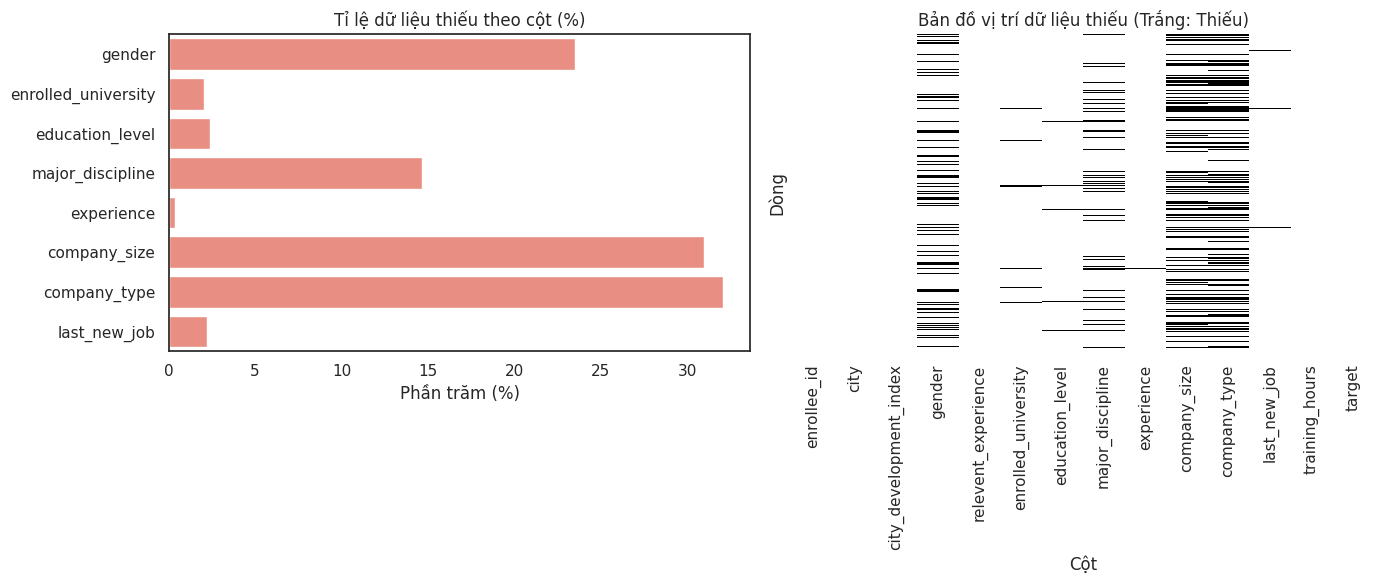

In [36]:
# Phân tích dữ liệu thiếu
print("=== PHÂN TÍCH DỮ LIỆU THIẾU (MISSING DATA ANALYSIS) ===\n")

is_missing_matrix = (data == '') | (data == 'nan')
print("--- Tổng quan dữ liệu thiếu ---")
missing_counts = np.einsum('ij->j', is_missing_matrix.astype(int))

total_rows = data.shape[0]
missing_pcts = (missing_counts / total_rows) * 100

print(f"{'Tên cột':<25} | {'Số lượng thiếu':<15} | {'Tỉ lệ (%)':<10}")

has_missing_mask = missing_counts > 0

missing_headers = headers[has_missing_mask]
missing_counts_filtered = missing_counts[has_missing_mask]
missing_pcts_filtered = missing_pcts[has_missing_mask]

for i in range(len(missing_headers)):
    print(f"{missing_headers[i]:<25} | {missing_counts_filtered[i]:<15} | {missing_pcts_filtered[i]:.2f}%")

missing_per_row = np.einsum('ij->i', is_missing_matrix.astype(int))

rows_with_missing = np.sum(missing_per_row > 0)

print(f"\nSố dòng có ít nhất 1 giá trị thiếu: {rows_with_missing} / {total_rows} ({rows_with_missing/total_rows*100:.2f}%)")
print(f"Số lượng giá trị thiếu trung bình mỗi dòng: {np.mean(missing_per_row):.2f}")

# Vẽ biểu đồ
vis.plot_missing_data(headers, missing_pcts, is_missing_matrix)

=== PHÂN TÍCH TƯƠNG QUAN (CORRELATION ANALYSIS) ===

Ma trận tương quan:
                          | city_dev   | hours      | target    
-----------------------------------------------------------------
city_development_index    | 1.0000     | 0.0019     | -0.3417   
training_hours            | 0.0019     | 1.0000     | -0.0216   
target                    | -0.3417    | -0.0216    | 1.0000    

> Nhận xét:
City Development Index vs Target: -0.3417
  -> Tương quan ÂM đáng kể: Thành phố càng phát triển, nhân sự càng ổn định.
Training Hours vs Target: -0.0216
  -> Tương quan rất thấp.


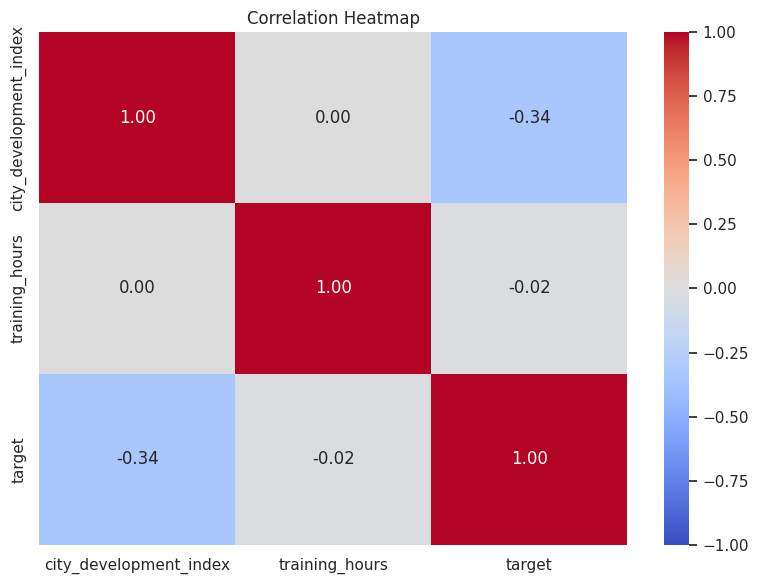


=== BẢNG CHÉO & THỐNG KÊ NHÓM ===

> Phân tích 'target' theo nhóm 'education_level':
education_level           | Mean target    
---------------------------------------------
Graduate                  | 0.2798         
Masters                   | 0.2144         
High School               | 0.1953         
Phd                       | 0.1401         
Primary School            | 0.1331         


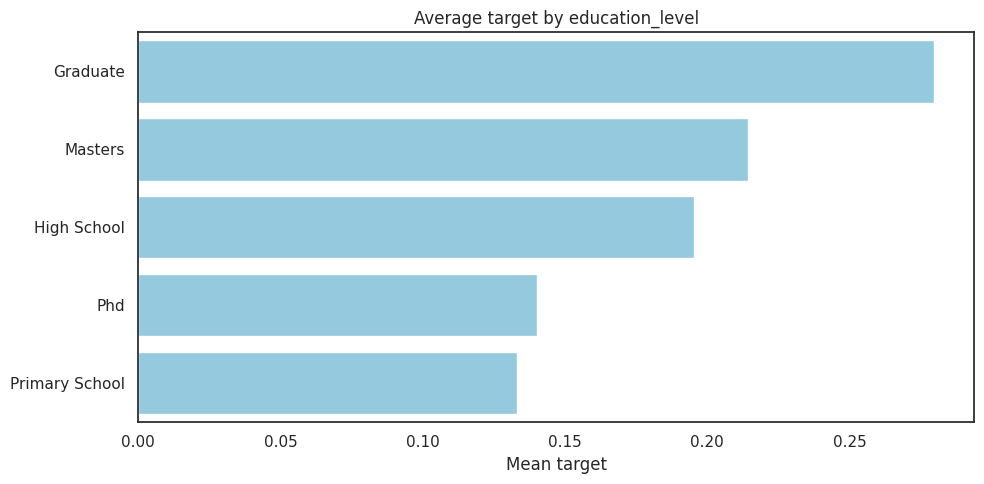


> Phân tích 'target' theo nhóm 'experience':
experience                | Mean target    
---------------------------------------------
<1                        | 0.4540         
1                         | 0.4244         
3                         | 0.3530         
2                         | 0.3319         
4                         | 0.3257         
7                         | 0.2947         
5                         | 0.2881         
6                         | 0.2821         
8                         | 0.2431         
11                        | 0.2274         
20                        | 0.2230         
9                         | 0.2173         
10                        | 0.2102         
13                        | 0.1930         
12                        | 0.1862         
14                        | 0.1826         
19                        | 0.1743         
17                        | 0.1667         
15                        | 0.1662         
18                        | 

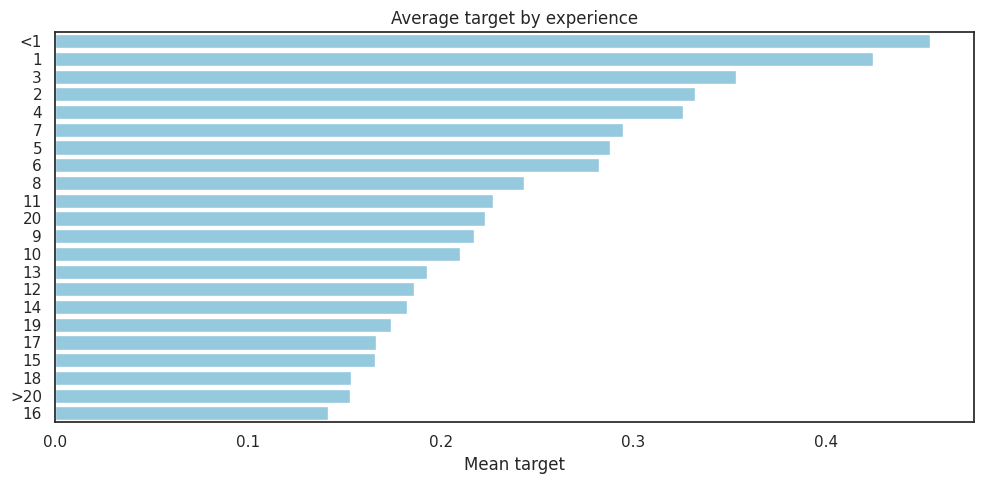


> Phân tích 'training_hours' theo nhóm 'company_type':
company_type              | Mean training_hours
---------------------------------------------
Early Stage Startup       | 69.4892        
Other                     | 69.0000        
NGO                       | 67.8560        
Funded Startup            | 66.9970        
Pvt Ltd                   | 65.2773        
Public Sector             | 62.0503        


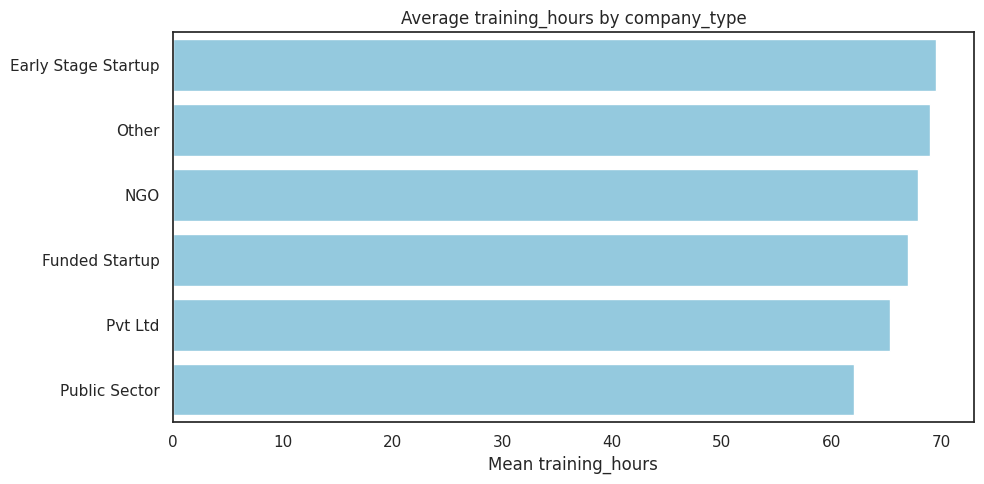

In [37]:
# Phân tích tương quan biến số
print("=== PHÂN TÍCH TƯƠNG QUAN (CORRELATION ANALYSIS) ===")

numeric_cols = ['city_development_index', 'training_hours', 'target']
num_indices = [np.where(headers == name)[0][0] for name in numeric_cols]


# Trích xuất dữ liệu 
raw_numeric_block = data[:, num_indices]

# Xử lý NaN vectorized 
raw_numeric_block[raw_numeric_block == ''] = 'nan'
raw_numeric_block[raw_numeric_block == 'nan'] = 'nan'

numeric_matrix = raw_numeric_block.astype(float)

# Tính tương quan 
corr_matrix = np.corrcoef(numeric_matrix, rowvar=False)

# In bảng kết quả (
print("\nMa trận tương quan:")
print(f"{'':<25} | {'city_dev':<10} | {'hours':<10} | {'target':<10}")
print("-" * 65)
for i, row_name in enumerate(numeric_cols):
    print(f"{row_name:<25} | {corr_matrix[i, 0]:<10.4f} | {corr_matrix[i, 1]:<10.4f} | {corr_matrix[i, 2]:<10.4f}")

# In nhận xét 
print("\n> Nhận xét:")
corr_city_target = corr_matrix[0, 2]
print(f"City Development Index vs Target: {corr_city_target:.4f}")
if corr_city_target < -0.3:
    print("  -> Tương quan ÂM đáng kể: Thành phố càng phát triển, nhân sự càng ổn định.")
else:
    print("  -> Tương quan yếu.")

corr_hours_target = corr_matrix[1, 2]
print(f"Training Hours vs Target: {corr_hours_target:.4f}")
print("  -> Tương quan rất thấp.")

# Vẽ biểu đồ
vis.plot_correlation_heatmap(corr_matrix, numeric_cols)


print("\n=== BẢNG CHÉO & THỐNG KÊ NHÓM ===")

def analyze_group_means(target_col, group_col):
    # Tìm index
    try:
        idx_target = np.where(headers == target_col)[0][0]
        idx_grp = np.where(headers == group_col)[0][0]
    except IndexError:
        print(f"Lỗi: Không tìm thấy cột {target_col} hoặc {group_col}")
        return

    # Lấy dữ liệu 
    raw_data_subset = data[:, [idx_target, idx_grp]]
    
    # Kiểm tra cả 2 cột không được rỗng/nan
    mask = (raw_data_subset != '') & (raw_data_subset != 'nan')
    # Chỉ giữ dòng mà CẢ 2 cột đều True (all axis 1)
    valid_rows_mask = np.all(mask, axis=1)
    
    clean_data = raw_data_subset[valid_rows_mask]
    
    v_target = clean_data[:, 0].astype(float)
    v_grp = clean_data[:, 1] # Vẫn là string
    
    print(f"\n> Phân tích '{target_col}' theo nhóm '{group_col}':")
 
    unique_groups, group_indices = np.unique(v_grp, return_inverse=True)
    
    # Tính tổng target 
    sums = np.bincount(group_indices, weights=v_target)
    
    #  Đếm số lượng phần tử mỗi nhóm
    counts = np.bincount(group_indices)
    
    # Tính trung bình (Vectorized division)
    means = sums / counts
    
    # Sắp xếp giảm dần (Array Manipulation) 
    sort_order = np.argsort(-means) 
    
    sorted_groups = unique_groups[sort_order]
    sorted_means = means[sort_order]
    
    # --- KẾT THÚC XỬ LÝ DỮ LIỆU ---

    # In bảng kết quả
    print(f"{group_col:<25} | {f'Mean {target_col}':<15}")
    print("-" * 45)
    
    results_for_plot = []
    for g, avg in zip(sorted_groups, sorted_means):
        print(f"{str(g)[:25]:<25} | {avg:<15.4f}")
        results_for_plot.append((g, avg))
        
    # Chuẩn bị dữ liệu để vẽ 
    groups = [str(x[0]) for x in results_for_plot]
    means_list = [x[1] for x in results_for_plot]
    
    # Vẽ biểu đồ 2
    vis.plot_group_means(groups, means_list, group_col, target_col)

# Thực hiện các phân tích
analyze_group_means('target', 'education_level')
analyze_group_means('target', 'experience')
analyze_group_means('training_hours', 'company_type')

#### NHẬN ĐỊNH và QUAN SÁT BAN ĐẦU

Sau quá trình khám phá dữ liệu, dưới đây là tóm tắt các phát hiện chính, các vấn đề về chất lượng dữ liệu:

##### 1. Tóm tắt Quan sát (Summary)

* **Mất cân bằng dữ liệu (Imbalance):** Bộ dữ liệu có sự chênh lệch lớn về nhãn mục tiêu. Chỉ có khoảng **25%** ứng viên thực sự muốn chuyển việc (Target = 1), trong khi 75% còn lại chọn ổn định.
    * *Hệ quả:* Mô hình sẽ dễ bị thiên kiến (bias) về nhóm đa số nếu không được xử lý.
* **Tương quan quan trọng:**
    * **`city_development_index` (Mạnh nhất):** Có tương quan nghịch biến **(-0.34)**. Thành phố càng phát triển, ứng viên càng có xu hướng ổn định công việc.
    * **`training_hours` (Yếu nhất):** Gần như không có tương quan (~0). Số giờ đào tạo nhiều hay ít không quyết định việc ứng viên đi hay ở.
* **Nghịch lý bằng cấp:** Nhóm **Graduate** (Cử nhân) có tỷ lệ muốn nhảy việc cao nhất (~28%), cao hơn cả nhóm trình độ thấp (Primary School) và nhóm trình độ cao (PhD).

#####  2. Vấn đề Chất lượng Dữ liệu (Data Quality Issues)

* **Dữ liệu thiếu có hệ thống (Not Missing At Random):**
    * Các cột `company_type` và `company_size` thiếu tới **~30-32%**.
    * *Phát hiện:* Việc thiếu dữ liệu này thường xảy ra đồng thời. Khả năng cao đây là nhóm ứng viên thất nghiệp, làm tự do (Freelancer) hoặc công ty nhỏ không được liệt kê.
* **Dữ liệu thiếu ở biến định danh:** Cột `gender` thiếu khoảng **23%**.
* **Tính nhất quán:** Dữ liệu dạng chuỗi (String) khá sạch, không phát hiện lỗi chính tả hay không đồng nhất (như "Male" vs "male").

#####  3. Interesting Patterns

* **Startup là nơi học hỏi:** Nhân sự làm việc tại các công ty **Early Stage Startup** có số giờ đào tạo trung bình cao nhất.
* **Sự ổn định của PhD:** Nhóm ứng viên có bằng Tiến sĩ (PhD) có tỷ lệ nhảy việc thấp nhất, cho thấy sự ổn định cao trong sự nghiệp của nhóm học thuật này.



#####  4. Cảnh báo & Giới hạn 
* **Những lo ngại nghiêm trọng về chất lượng dữ liệu:**
Việc thiếu dữ liệu quá lớn ở các thông tin về công ty (company_size, company_type) có thể làm sai lệch kết quả nếu chúng ta cố gắng phân tích mối liên hệ giữa môi trường làm việc và quyết định nhảy việc. Nếu điền dữ liệu giả (imputation) không khéo léo sẽ tạo ra bias (thiên kiến).
* **Hạn chế có thể ảnh hưởng đến phân tích:**
Imbalanced Dataset: Với tỷ lệ 75:25, nếu không xử lý (như dùng kỹ thuật SMOTE hoặc điều chỉnh class weights), mô hình máy học sẽ có xu hướng dự đoán toàn bộ là "Không nhảy việc" (Class 0) để đạt độ chính xác ảo cao nhưng lại thất bại trong việc tìm ra những người thực sự muốn nhảy việc (Class 1).

### Câu hỏi 1: Giới tính có ảnh hưởng đến khả năng thay đổi công việc không?


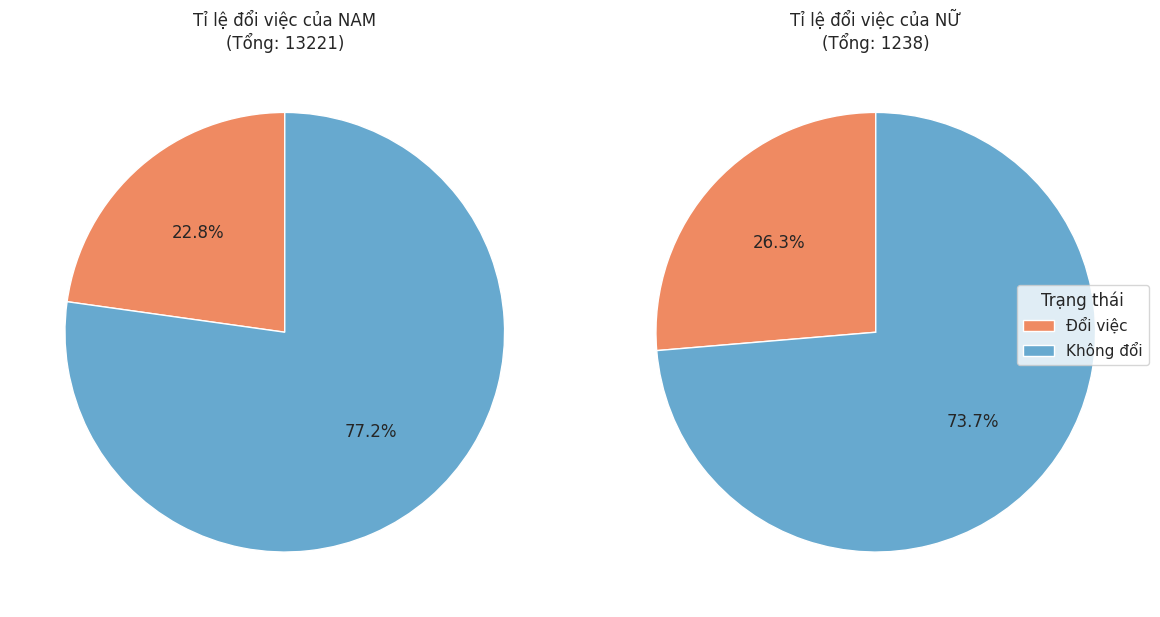

In [39]:
gender_idx = np.where(headers == "gender")[0][0]
target_idx = np.where(headers == "target")[0][0]

# Lấy giá trị
gender = data[:, gender_idx]
target = data[:, target_idx].astype(float).astype(int)

# Tách theo giới tính
is_male = gender == "Male"
is_female = gender == "Female"

# Tổng số Nam/Nữ
total_male = np.sum(is_male)
total_female = np.sum(is_female)

# Nam: đổi việc / không đổi việc
male_change = np.sum((target == 1) & is_male)
male_nochange = np.sum((target == 0) & is_male)

# Nữ: đổi việc / không đổi việc
female_change = np.sum((target == 1) & is_female)
female_nochange = np.sum((target == 0) & is_female)

# Tạo list size để truyền vào hàm vẽ
sizes_male = [male_change, male_nochange] 
sizes_female = [female_change, female_nochange]

# Vẽ biểu đồ
vis.plot_gender_pie_charts(sizes_male, sizes_female, total_male, total_female)

**Trả lời:** Dựa vào 2 biểu đồ ta thấy có sự chênh lệch nhẹ về giới tính: Nữ giới có xu hướng thay đổi công việc cao hơn nam giới một chút (26.3% so với 22.8%). Mức chênh lệch là khoảng 3.5% nên không đáng kể. Tuy nhiên lưu ý việc mất cân bằng giữa giới tính trong dữ liệu (13221 nam và 1238 nữ) dễ gây ra dự đoán sai lệch

### Câu hỏi 2: Chỉ số phát triển của một thành phố có ảnh hưởng đến số giờ đào tạo trung bình của ứng viên ở đó không?

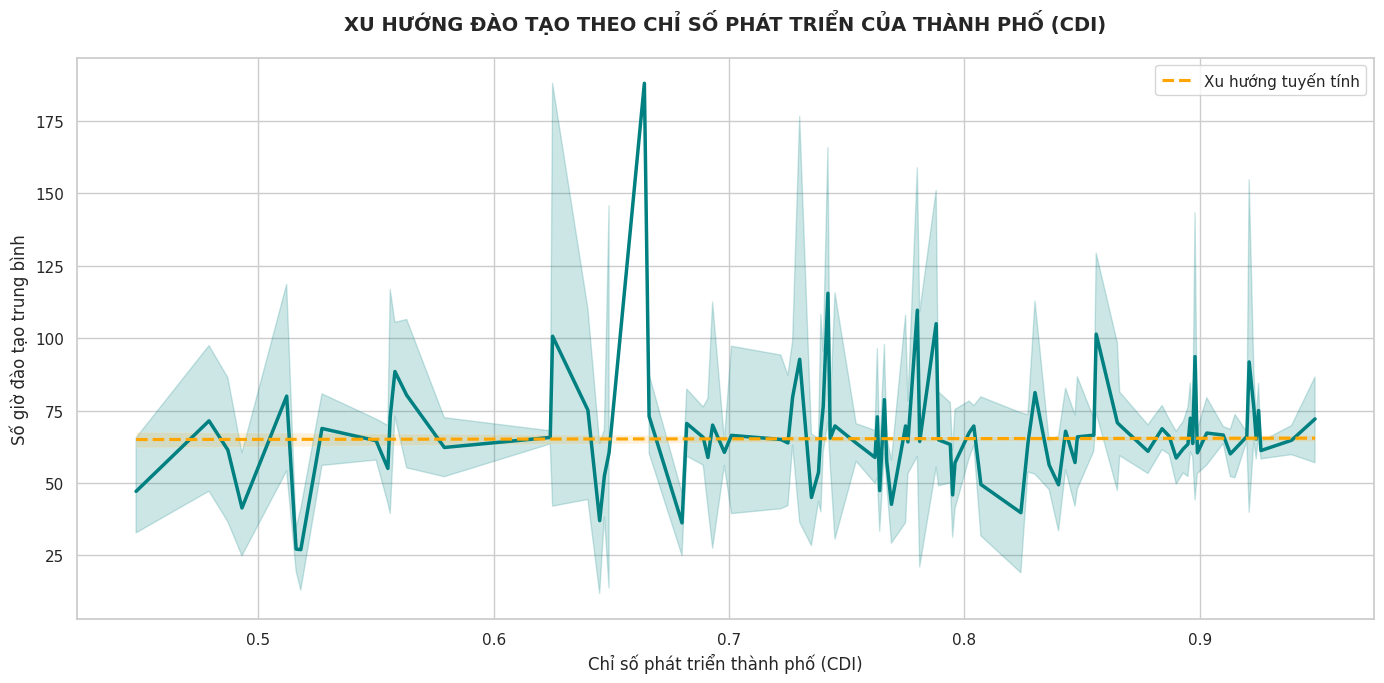

In [26]:
cdi_idx = np.where(headers == 'city_development_index')[0][0]
hours_idx = np.where(headers == 'training_hours')[0][0]

# Lấy dữ liệu thô
raw_cdi = data[:, cdi_idx]
raw_hours = data[:, hours_idx]

# Lọc bỏ các giá trị rỗng hoặc 'nan'
valid_mask = (raw_cdi != '') & (raw_hours != '') & (raw_cdi != 'nan') & (raw_hours != 'nan')

# Chuyển sang số thực (float)
# Làm tròn CDI để nhóm dữ liệu tốt hơn
cdi = raw_cdi[valid_mask].astype(float).round(3) 
hours = raw_hours[valid_mask].astype(float)

# Vẽ biểu đồ
vis.plot_cdi_vs_training_hours(cdi, hours)

**Trả lời:** Qua biểu đồ ta có thể thấy độ phát triển của một thành phố không quyết định mức độ được đào tạo của một nhân viên. Dựa vào đường xu hướng tuyến tính (nét đứt màu vàng), ta thấy nó gần như nằm ngang và song song với trục hoành. Điều này chứng minh hệ số tương quan gần như bằng 0. Tức là: Dù một nhân sự sống ở thành phố kém phát triển (CDI thấp) hay thành phố hiện đại (CDI cao), số giờ họ dành cho việc đào tạo trung bình vẫn ổn định ở mức ~60 - 65 giờ như những nhân sự sống ở những thành phố phát triển

### Câu hỏi 3: Các ứng viên có nhiều kinh nghiệm có dễ ổn định công việc hơn không?


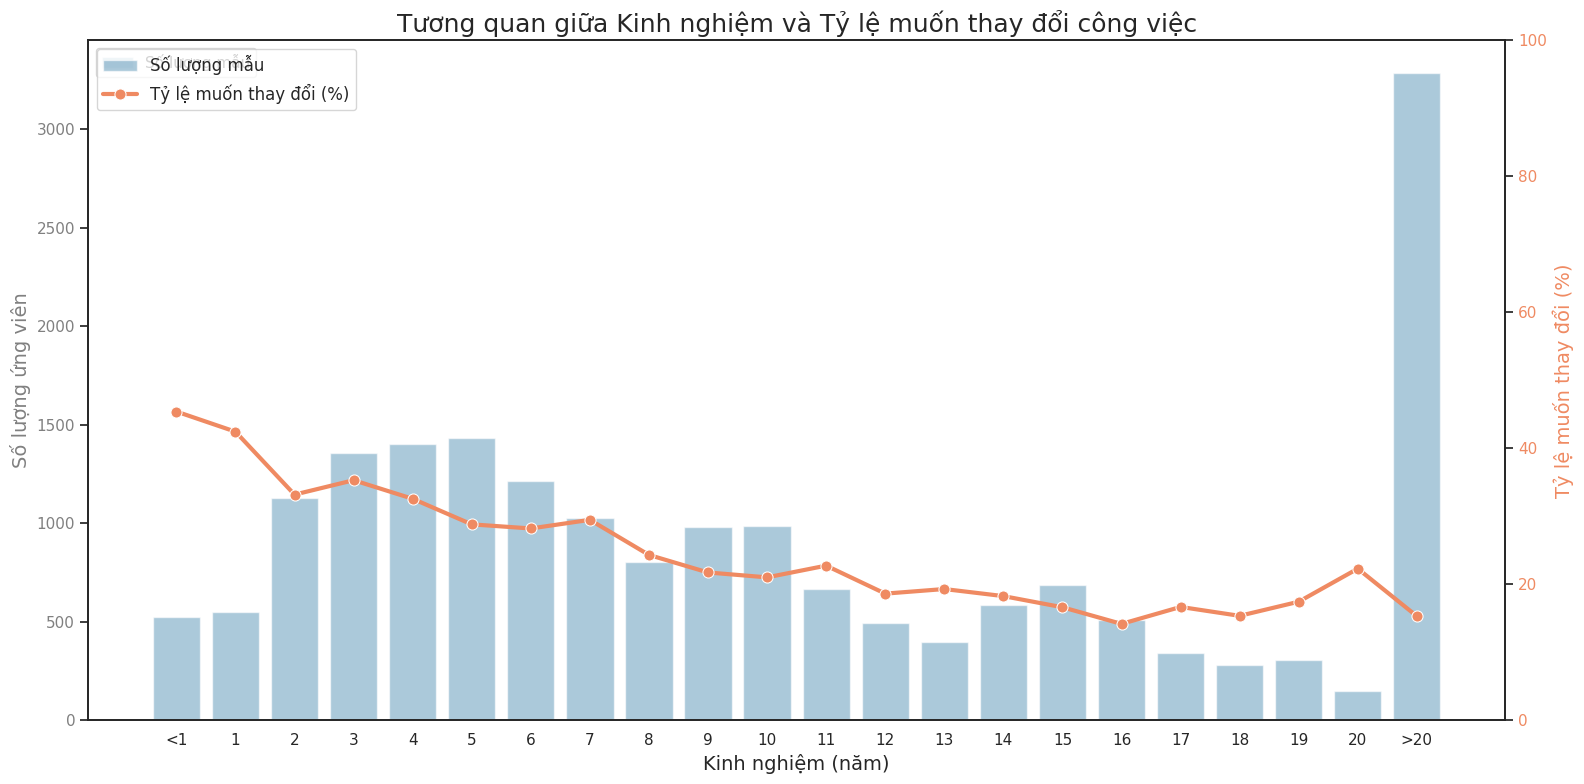

In [40]:
# Chuẩn bị dữ liệu 
exp_idx = np.where(headers == 'experience')[0][0]
target_idx = np.where(headers == 'target')[0][0]

exp_col = data[:, exp_idx]
target_col = data[:, target_idx]

# Lọc dữ liệu rỗng 
mask = (exp_col != '') & (target_col != '') & (target_col != 'nan')
exp_data_str = exp_col[mask]
target_numeric = target_col[mask].astype(float)

# Định nghĩa thứ tự hiển thị trục X
exp_order = ['<1'] + [str(i) for i in range(1, 21)] + ['>20']
exp_order_arr = np.array(exp_order) 

# Tạo Ma trận Mask 
group_mask_matrix = (exp_data_str[:, np.newaxis] == exp_order_arr)

# Tính số lượng Sum theo cột
y_counts = np.sum(group_mask_matrix, axis=0)

# Tính tổng Target theo nhóm 
# 'nk,n->k': Nhân mask (n,k) với target (n), cộng dồn theo n
target_sums = np.einsum('nk,n->k', group_mask_matrix.astype(float), target_numeric)

# Tính phần trăm (Mean = Sum / Count)
# Xử lý chia cho 0 (với các nhóm không có dữ liệu)
with np.errstate(divide='ignore', invalid='ignore'):
    mean_vals = target_sums / y_counts

# Thay thế NaN (do 0/0) thành 0.0
mean_vals = np.nan_to_num(mean_vals) 

# Chuẩn bị mảng để vẽ
percentages_want_change = mean_vals 
y_want_change_100 = percentages_want_change * 100

# Vẽ biểu đồ
vis.plot_experience_vs_target(exp_order, y_counts, y_want_change_100)

**Trả lời:** Qua biểu đồ ta có thể thấy thâm niên làm việc là yếu tố quan trọng định hình mức độ ổn định của nhân sự. Dựa vào đường biểu diễn tỷ lệ thay đổi công việc (nét màu cam), ta thấy nó có xu hướng dốc xuống rõ rệt từ trái sang phải. Điều này chứng minh tồn tại một mối tương quan nghịch biến (tương quan âm) giữa thời gian làm việc và nhu cầu nhảy việc. Tức là: Khi một nhân sự càng tích lũy được nhiều năm kinh nghiệm, xu hướng muốn tìm kiếm công việc mới của họ càng giảm đi; từ mức rất cao (45%) ở giai đoạn mới vào nghề xuống mức thấp và ổn định (15-20%) ở giai đoạn thâm niên (trên 15 năm).